# Week 5: Task 3 - Housing Price Prediction
## Exploratory Data Analysis (Monday Deliverable)

### 1. Project Context & Objectives
- **Internship**: Arch Technologies - Machine Learning Domain (Month 2)
- **Task**: Predict `median_house_value` using California census block attributes:
  - Location: `longitude`, `latitude`, `ocean_proximity`
  - Property Specs: `housing_median_age`, `total_rooms`, `total_bedrooms`
  - Demographics: `population`, `households`, `median_income`
- **Objective**: Conduct rigorous data exploration to inspect dimensions, data types, statistical distributions, missing values, and anomalies.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual formatting configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10

# Load California Housing Dataset
DATA_PATH = Path("../data/california-dataset.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("week-5/data/california-dataset.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset successfully loaded. Total rows: {df.shape[0]:,}, Columns: {df.shape[1]}")
df.head()

Dataset successfully loaded. Total rows: 20,640, Columns: 10

### 2. Dataset Structure & Data Types
Inspecting dimensions, column data types, and non-null entry counts using `.shape`, `.dtypes`, and `.info()`.

In [2]:
print("Dataset Dimensions (Rows, Columns):", df.shape)
print("
--- Column Data Types ---")
print(df.dtypes)
print("
--- Detailed DataFrame Info ---")
df.info()

Dataset Dimensions (Rows, Columns): (20640, 10)

--- Column Data Types ---
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

--- Detailed DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null

### 3. Summary Statistics
Examine the count, mean, standard deviation, quartiles, and min/max ranges for all numerical features via `.describe()`.

In [3]:
# Display numerical summary statistics
summary_stats = df.describe().T
print(summary_stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])
summary_stats

                      count           mean  ...           75%          max
longitude           20640.0    -119.569704  ...    -118.01000    -114.3100
latitude            20640.0      35.631861  ...      37.71000      41.9500
housing_median_age  20640.0      28.639486  ...      37.00000      52.0000
total_rooms         20640.0    2635.763081  ...    3148.00000   39320.0000
total_bedrooms      20433.0     537.870553  ...     647.00000    6445.0000
population          20640.0    1425.476744  ...    1725.00000   35682.0000
households          20640.0     499.539680  ...     605.00000    6082.0000
median_income       20640.0       3.870671  ...       4.74325      15.0001
median_house_value  20640.0  206855.816909  ...  264725.00000  500001.0000

[9 rows x 8 columns]

**Key Observations from Summary Statistics:**
- **Income Scale**: `median_income` ranges from approximately 0.5 to 15.0, representing tens of thousands of USD (e.g. 3.5 represents $35,000).
- **Target Value Cap**: `median_house_value` has a 75th percentile of $264,725 and a max value capped exactly at $500,001.
- **Median Age Cap**: `housing_median_age` max is capped at 52 years.
- **Heavy Skewness**: Features like `total_rooms`, `total_bedrooms`, `population`, and `households` display significant disparity between the 75th percentile and maximum values, indicating long right tails.

### 4. Missing Values Analysis
Check and report missing values per column across the dataset.

In [4]:
# Identify and quantify missing values
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().sum() / len(df)) * 100
})
print("Missing values report:")
print(missing_df)

Missing values report:
                    Missing Values  Percentage (%)
longitude                        0        0.000000
latitude                         0        0.000000
housing_median_age               0        0.000000
total_rooms                      0        0.000000
total_bedrooms                 207        1.002907
population                       0        0.000000
households                       0        0.000000
median_income                    0        0.000000
median_house_value               0        0.000000
ocean_proximity                  0        0.000000

**Missing Value Finding**:
- Only `total_bedrooms` contains missing values: **207 missing entries** (~1.00% of the dataset).
- All other 9 columns are 100% complete without nulls.

### 5. Categorical Feature Analysis (`ocean_proximity`)
Examine the unique categories, distribution, and sample counts for the categorical variable.

Ocean Proximity Value Counts:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

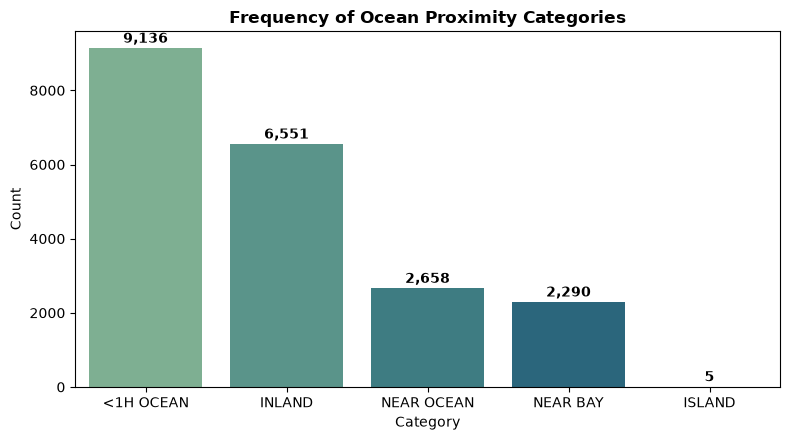

In [5]:
print("Ocean Proximity Value Counts:")
print(df["ocean_proximity"].value_counts())

plt.figure(figsize=(8, 4.5))
sns.barplot(x=df["ocean_proximity"].value_counts().index, 
            y=df["ocean_proximity"].value_counts().values, 
            palette="crest", hue=df["ocean_proximity"].value_counts().index, legend=False)
plt.title("Frequency of Ocean Proximity Categories", fontsize=12, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 6. Distribution Plots (Histograms for Numeric Columns)
Visualizing distributions and probability density approximations for all numeric features.

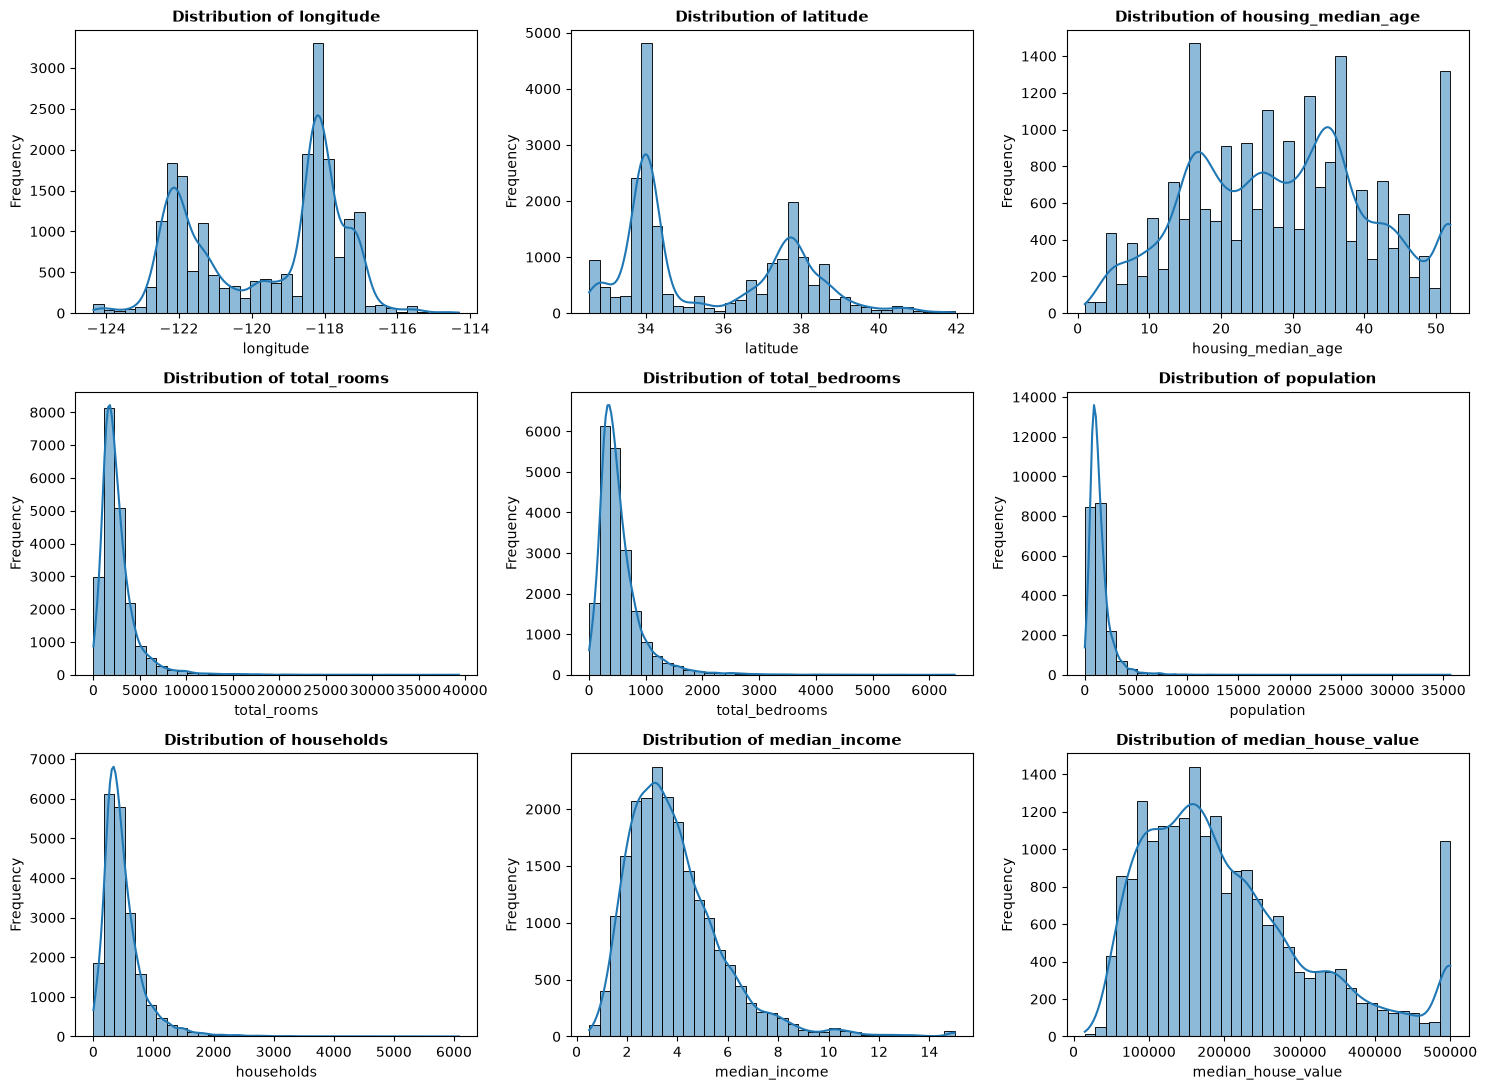

In [6]:
# Plot distribution histograms for all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3, i % 3]
    sns.histplot(df[col], kde=True, bins=35, color="#1f77b4", ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 7. Geographic Price Distribution
Visualizing California geography using `longitude` and `latitude`, color-coded by `median_house_value` and scaled by `population`.

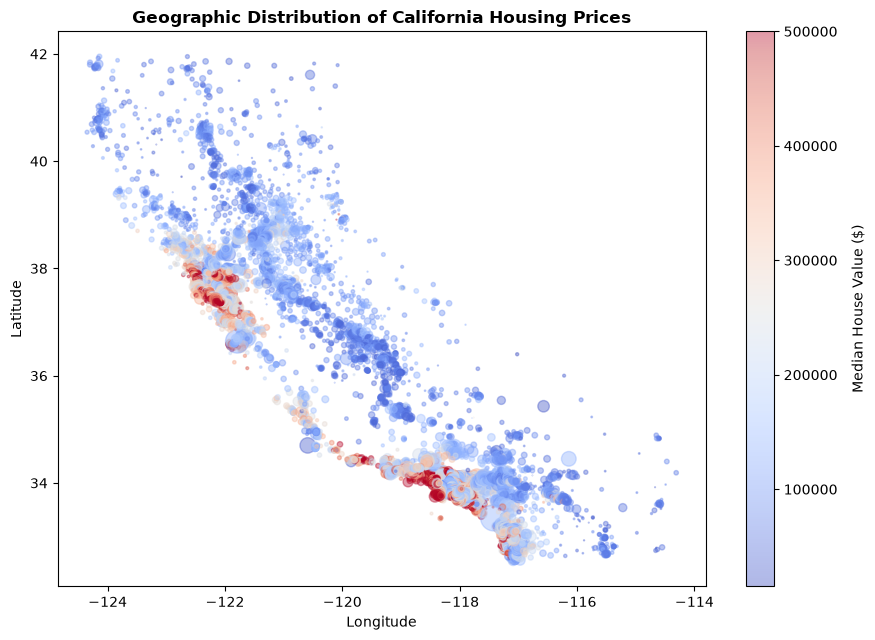

In [7]:
# Geographic scatter plot
plt.figure(figsize=(9, 6.5))
scatter = plt.scatter(
    df["longitude"], df["latitude"],
    c=df["median_house_value"], cmap="coolwarm", alpha=0.4,
    s=df["population"] / 100, label="Population"
)
cbar = plt.colorbar(scatter)
cbar.set_label("Median House Value ($)", labelpad=10)
plt.title("Geographic Distribution of California Housing Prices", fontsize=12, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

### 8. Summary of Monday EDA Findings
1. **Dataset Volume**: 20,640 records across 10 features (9 numeric, 1 categorical).
2. **Missing Values**: Only `total_bedrooms` has 207 missing values; imputation required during Tuesday's cleaning.
3. **Categorical Encoding**: `ocean_proximity` has 5 distinct labels (`<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`) requiring One-Hot Encoding.
4. **Target & Age Truncation**: Both `median_house_value` ($500,001) and `housing_median_age` (52) exhibit artificial capping.
5. **Spatial Patterns**: Coastal and Bay Area districts demonstrate substantially higher property valuations compared to inland areas.